<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/01_pandas_for_clinical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 01 of the course** · [Next: 02 — Cleaning messy clinical data ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/02_data_cleaning.ipynb)


# 🩺 Notebook 01 — Pandas for clinical data

> You already know how to read a patient's chart. This notebook teaches you to read
> a **whole ICU's worth of charts at once** — using `pandas`, the spreadsheet-on-steroids
> library that powers almost all data work in Python.

We will answer *clinical* questions ("How many of my over-65s had a raised lactate?",
"What happened to this patient's blood pressure hour by hour?") and learn the pandas tools
as a side-effect. No prior Python needed — just run each cell and read along.

**What you'll learn**
- How a longitudinal ICU dataset is laid out (**one row per patient per 4-hour block**)
- Selecting columns and **filtering** rows the way you'd filter a ward list
- Following **one patient's journey** over time and plotting it
- **`groupby`** — the single most useful verb for turning many rows into one-per-patient answers
- Handling **dates/times**, **reshaping** (pivot/melt), and **merging** two tables
- A first peek at **missing data** (the star of Notebook 02)

**⏱️ Time:** ≈55 min · **Prerequisites:** none — this is your starting point.


## ⚙️ Run me first

The cell below sets everything up: it installs any missing packages, configures nice-looking
plots, and defines the helpers that load the data. **Just run it** — you don't need to understand
it yet. (It's identical in every notebook of this course.)


In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


## 📂 Load the data

Our dataset is a small, de-identified teaching subset of a real ICU database.
Each patient here has **sepsis**, a life-threatening response to infection. We load the
*time-series* file: the longitudinal record of vitals, labs and treatments over each ICU stay.


In [2]:
df = load_csv("sepsis_timeseries.csv")

✓ loaded data/sepsis_timeseries.csv


## 👀 Meet the data

Think of `df` (short for *DataFrame*) as one giant spreadsheet. Two numbers describe its size:
**rows × columns**. `df.shape` reports them.


In [3]:
df.shape

(37704, 53)

≈37,700 rows and 53 columns. But it is **not** 37,700 patients. The crucial idea:

> **One row = one patient during one 4-hour block of their ICU stay.**

A patient who stayed 3 days contributes ≈18 rows (18 blocks × 4 h). `df.head()` shows the
first few rows — watch the first column, `icustayid`, stay the same while `bloc` counts up.


In [4]:
df.head()

,icustayid,bloc,timestep,age,gender,Weight_kg,Height_cm,elixhauser,re_admission,GCS,HR,SysBP,MeanBP,DiaBP,RR,SpO2,Temp_C,Temp_F,Potassium,Sodium,Chloride,Glucose,BUN,Creatinine,Calcium,Ionised_Ca,Magnesium,CO2_mEqL,Albumin,Total_bili,Hb,WBC_count,Platelets_count,INR,Arterial_pH,paO2,paCO2,Arterial_lactate,HCO3,SaO2,FiO2_1,PEEP,mechvent,input_step,output_step,cumulated_balance,max_dose_vaso,Shock_Index,PaO2_FiO2,SOFA,SIRS,morta_90,died_in_hosp
0,30003226,1,4833101040,67,0,91.8,NaN,4,False,15.0,83.40,141.75,88.00,61.12,16.60,97.89,37.28,99.10,2.90,149.00,105.00,252.33,13.0,0.6,9.8,1.04,1.8,27.00,3.0,1.2,8.0,9.30,357.0,2.70,7.42,171.0,38.0,2.0,28.0,NaN,0.32,5.0,0,181.66,65.0,2116.67,0.0,0.59,534.38,1,0,0,0
1,30003226,2,4833115440,67,0,91.8,NaN,4,False,15.0,69.71,147.86,87.29,57.00,13.29,95.86,37.55,99.59,6.80,135.00,93.00,112.43,63.0,18.2,8.6,0.97,1.9,23.00,2.3,1.3,7.3,8.30,225.0,1.07,7.31,64.0,42.0,1.1,24.0,NaN,0.34,5.0,0,200.92,65.0,2252.59,0.0,0.47,186.67,7,0,0,0
2,30003226,3,4833129840,67,0,91.8,NaN,4,False,15.0,66.25,169.50,101.50,67.50,15.25,99.50,37.43,99.38,6.80,135.00,93.00,109.00,63.0,18.2,8.6,0.97,1.9,21.00,2.3,0.7,6.6,7.17,197.0,1.50,7.22,64.0,42.0,0.6,24.0,NaN,0.36,8.0,0,200.92,80.0,2373.51,0.0,0.39,177.78,6,0,0,0
3,30003226,4,4833144240,67,0,91.8,NaN,4,False,15.0,72.12,145.50,87.25,48.75,14.75,98.62,37.51,99.51,6.10,135.88,95.62,119.00,64.0,18.1,8.6,0.97,2.0,23.25,2.3,0.7,7.3,8.30,225.0,1.30,7.35,64.0,42.0,1.0,23.0,NaN,0.36,5.0,0,210.92,35.0,2549.43,0.0,0.50,177.78,6,0,0,0
4,30003226,5,4833158640,67,0,91.8,NaN,4,False,15.0,75.25,134.00,104.12,32.00,14.12,99.25,37.19,98.94,5.45,137.00,96.00,94.50,64.0,18.1,8.6,1.04,2.0,23.67,2.3,0.7,7.3,8.30,225.0,1.10,7.39,127.0,43.0,0.8,23.0,NaN,0.36,0.0,0,200.92,62.0,2688.35,0.0,0.56,352.78,4,0,0,0


Three columns you'll use constantly:

| column | what it is | clinical analogy |
|---|---|---|
| `icustayid` | the **patient key** — one ICU stay | the medical record number |
| `bloc` | the 4-hour block number within the stay (1, 2, 3 …) | "hour 0–4", "hour 4–8" … |
| `morta_90` | **did the patient die within 90 days?** (1 = died) | the outcome we ultimately want to predict |

Let's confirm the shape of the cohort: how many **distinct patients**, and how many died?


In [5]:
n_stays = df["icustayid"].nunique()
# morta_90 is constant within a stay, so take one value per patient before averaging
mortality_rate = df.groupby("icustayid")["morta_90"].max().mean()
print(f"Distinct ICU stays : {n_stays:,}")
print(f"Total rows (blocks): {len(df):,}")
print(f"90-day mortality   : {mortality_rate:.1%} of stays")

Distinct ICU stays : 1,696
Total rows (blocks): 37,704
90-day mortality   : 18.2% of stays


> 🧠 **Clinical takeaway.** ≈18% of these sepsis patients died within 90 days — a sobering
> baseline. Notice we had to **collapse to one row per patient** (`groupby(...).max()`) before
> computing the mortality rate. Averaging `morta_90` over all 37k rows would over-weight patients
> who stayed longer. This one-row-per-block layout is the theme of the whole course.

`df.info()` lists every column, its type, and how many values are non-missing. Already you can
spot trouble: some columns are far from full.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37704 entries, 0 to 37703
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   icustayid          37704 non-null  int64  
 1   bloc               37704 non-null  int64  
 2   timestep           37704 non-null  int64  
 3   age                37704 non-null  int64  
 4   gender             37704 non-null  int64  
 5   Weight_kg          34312 non-null  float64
 6   Height_cm          22756 non-null  float64
 7   elixhauser         37704 non-null  int64  
 8   re_admission       37704 non-null  bool   
 9   GCS                37704 non-null  float64
 10  HR                 37704 non-null  float64
 11  SysBP              37704 non-null  float64
 12  MeanBP             37704 non-null  float64
 13  DiaBP              37704 non-null  float64
 14  RR                 37704 non-null  float64
 15  SpO2               37704 non-null  float64
 16  Temp_C             37704 non-null

`df.describe()` gives summary statistics for the numeric columns — count, mean, min, max and
quartiles. Scan the **min** and **max** rows: they're a fast lie-detector for a dataset.


In [7]:
df.describe()

,icustayid,bloc,timestep,age,gender,Weight_kg,Height_cm,elixhauser,GCS,HR,SysBP,MeanBP,DiaBP,RR,SpO2,Temp_C,Temp_F,Potassium,Sodium,Chloride,Glucose,BUN,Creatinine,Calcium,Ionised_Ca,Magnesium,CO2_mEqL,Albumin,Total_bili,Hb,WBC_count,Platelets_count,INR,Arterial_pH,paO2,paCO2,Arterial_lactate,HCO3,SaO2,FiO2_1,PEEP,mechvent,input_step,output_step,cumulated_balance,max_dose_vaso,Shock_Index,PaO2_FiO2,SOFA,SIRS,morta_90,died_in_hosp
count,3.770400e+04,37704.000000,3.770400e+04,37704.000000,37704.000000,34312.000000,22756.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,2342.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.000000,37704.00000,37704.000000,37704.000000
mean,3.492519e+07,19.547396,5.801527e+09,66.344685,0.427647,81.872511,168.096025,5.231540,13.380036,84.514762,120.940022,80.594013,60.233025,19.620874,96.709312,36.863472,98.906311,4.113066,138.846541,102.999923,142.075414,31.625073,1.817615,8.502877,1.126466,2.130326,27.286289,3.050700,1.918712,9.919650,13.139044,204.509860,1.426055,7.407975,106.699408,43.582683,1.823135,24.588916,95.273608,0.368825,6.060905,0.363171,460.328888,260.449050,7401.634618,0.038884,0.722154,327.625834,4.740425,1.33328,0.251538,0.152583
std,2.921721e+06,16.723075,7.638313e+08,15.479225,0.494744,23.980414,14.374842,2.407709,3.163323,16.514839,19.766376,13.712742,14.704457,5.074499,2.732870,0.616636,31.858385,0.553006,5.586196,6.627612,52.887803,24.770564,2.332356,0.739323,0.088631,0.361350,5.987738,0.649922,4.645247,2.026274,16.516789,128.036065,0.693053,0.065549,73.944188,12.299356,1.358897,4.935423,3.420710,0.160027,2.771859,0.480920,1204.491007,345.493844,29839.164865,0.308406,0.541099,265.755078,2.997672,0.99149,0.433903,0.359590
min,3.000323e+07,1.000000,4.419813e+09,18.000000,0.000000,1.000000,13.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,9.220000,-99.900000,1.700000,105.360000,71.000000,42.000000,1.000000,0.000000,0.000000,0.500000,0.900000,0.000000,1.000000,0.100000,-0.420000,0.100000,5.000000,0.500000,6.960000,5.000000,12.000000,0.300000,5.570000,62.000000,0.210000,0.000000,0.000000,0.000000,0.000000,-68427.700000,0.000000,0.000000,23.810000,0.000000,0.00000,0.000000,0.000000
25%,3.244514e+07,6.000000,5.170548e+09,57.000000,0.000000,65.800000,160.000000,3.000000,14.000000,72.750000,106.500000,70.750000,50.170000,16.250000,95.250000,36.600000,97.890000,3.700000,136.000000,99.000000,107.000000,15.000000,0.700000,8.000000,1.080000,1.900000,23.000000,2.600000,0.400000,8.400000,7.500000,123.000000,1.100000,7.370000,57.110000,36.000000,1.100000,21.500000,94.000000,0.240000,5.000000,0.000000,0.000000,0.000000,-1796.000000,0.000000,0.580000,163.080000,3.000000,1.00000,0.000000,0.000000
50%,3.473643e+07,14.000000,5.783943e+09,68.000000,0.000000,78.000000,170.000000,5.000000,15.000000,83.555000,119.100000,78.770000,59.020000,19.170000,97.000000,36.840000,98.315000,4.050000,139.000000,103.000000,129.000000,23.000000,1.070000,8.500000,1.130000,2.100000,26.450000,3.000000,0.600000,9.600000,10.300000,185.000000,1.200000,7.410000,90.000000,41.000000,1.500000,24.000000,96.000000,0.350000,5.000000,0.000000,48.040000,170.000000,741.800000,0.000000,0.700000,257.605000,4.000000,1.00000,0.000000,0.000000
75%,3.752493e+07,29.000000,6.469522e+09,78.000000,1.000000,95.100000,178.000000,7.000000,15.000000,95.400000,133.800000,89.000000,69.372500,22.500000,98.670000,37.110000,98.800000,4.400000,142.000000,107.000000,161.897500,41.000000,1.900000,8.900000,1.170000,2.300000,30.000000,3.500000,1.300000,11.200000,14.200000,257.000000,1.500000,

> 🧠 **Clinical takeaway.** Look at `Temp_F`: a **max around 3900 °F** and a **min of −99.9**.
> No patient is that hot or that cold — these are unit mix-ups and missing-data sentinels. `HR`
> and `MeanBP` also have impossible minima (0, 1). Real hospital data is *messy*. Spotting these
> is exactly the job of Notebook 02; for now, just know they're there.


## 🔎 Selecting & filtering — building a ward list

Two everyday operations: pick the **columns** you care about, and keep only the **rows** that
match a condition — just like filtering a patient list.

**Select columns** by passing a list of names in `[[ ]]`:


In [8]:
df[["icustayid", "bloc", "age", "HR", "MeanBP", "Arterial_lactate"]].head()

,icustayid,bloc,age,HR,MeanBP,Arterial_lactate
0,30003226,1,67,83.40,88.00,2.0
1,30003226,2,67,69.71,87.29,1.1
2,30003226,3,67,66.25,101.50,0.6
3,30003226,4,67,72.12,87.25,1.0
4,30003226,5,67,75.25,104.12,0.8


**Filter rows** with a boolean condition. This reads almost like English —
"rows where age is greater than 65":


In [9]:
older = df[df["age"] > 65]
print(f"{len(older):,} rows belong to patients over 65 "
      f"({older['icustayid'].nunique():,} distinct stays)")

20,976 rows belong to patients over 65 (926 distinct stays)


Combine conditions with `&` (and) / `|` (or) — **each condition in its own parentheses**.
Here: hypotensive *and* on a vasopressor at the same block.


In [10]:
shocky = df[(df["MeanBP"] < 65) & (df["max_dose_vaso"] > 0)]
shocky[["icustayid", "bloc", "MeanBP", "max_dose_vaso", "Arterial_lactate"]].head()

,icustayid,bloc,MeanBP,max_dose_vaso,Arterial_lactate
267,30047367,1,60.57,0.14,1.20
268,30047367,2,63.33,0.14,1.40
356,30055897,1,64.89,0.90,1.80
374,30055897,19,61.00,0.22,1.45
375,30055897,20,64.50,0.45,1.70


### `.loc`, `.iloc`, and `.query()`

- **`.iloc`** selects by **position** (like a grid reference): `df.iloc[0, 1]` = row 0, column 1.
- **`.loc`** selects by **label** — row index and *column name* — and is the safe way to both
  read *and* write. `.loc[rows, cols]`.
- **`.query()`** lets you write the filter as a readable string.

All three below pull the same idea; pick whichever reads best to you.


In [11]:
# positional: first 3 rows, first 4 columns
print("iloc:\n", df.iloc[:3, :4], "\n")

# label-based: rows where SOFA >= 12, showing three columns
print("loc:\n", df.loc[df["SOFA"] >= 12, ["icustayid", "bloc", "SOFA"]].head(3), "\n")

# query string — note the quotes and column names bare
print("query:\n", df.query("age > 80 and Arterial_lactate > 4")
      [["icustayid", "age", "Arterial_lactate"]].head(3))

iloc:
    icustayid  bloc    timestep  age
0   30003226     1  4833101040   67
1   30003226     2  4833115440   67
2   30003226     3  4833129840   67 

loc:
      icustayid  bloc  SOFA
238   30037708     9    12
239   30037708    10    12
286   30049254     3    13 

query:
       icustayid  age  Arterial_lactate
207    30031362   83               4.5
405    30055897   91               4.4
1016   30233300   82               5.3


Let's put filtering to visual use. Below, the **age distribution** of the cohort — sepsis is
predominantly a disease of older adults.


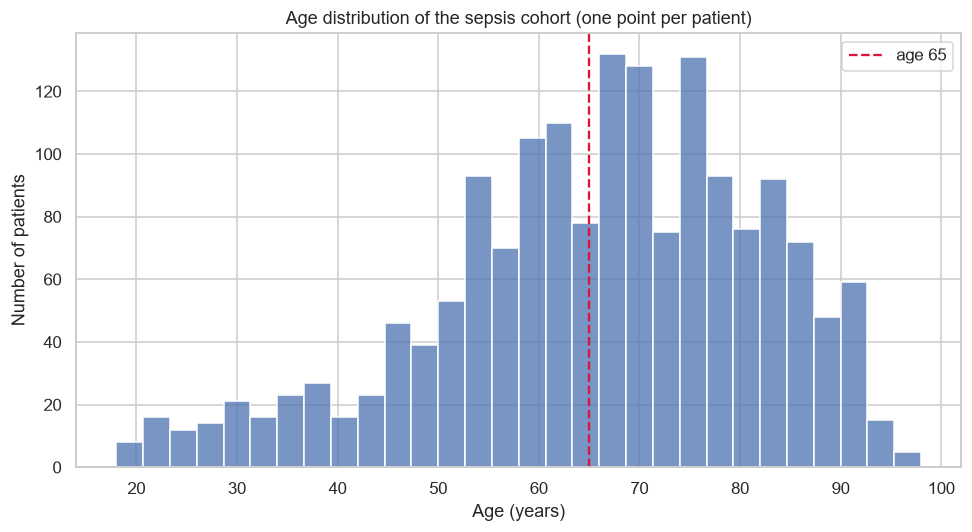

In [12]:
fig, ax = plt.subplots()
sns.histplot(data=df.groupby("icustayid").first(), x="age", bins=30,
             color="#4C72B0", edgecolor="white", ax=ax)
ax.axvline(65, color="crimson", linestyle="--", label="age 65")
ax.set(title="Age distribution of the sepsis cohort (one point per patient)",
       xlabel="Age (years)", ylabel="Number of patients")
ax.legend()
plt.tight_layout(); plt.show()

We used `groupby("icustayid").first()` so each patient is counted **once** (age is constant
within a stay). The dashed line marks 65 — most of the mass sits to its right.


### ✏️ Your turn — exercise 1

*"Among patients **over 65**, how many had a **maximum lactate above 2 mmol/L** at any point?"*

A raised lactate signals poor tissue perfusion. This needs a **`groupby`** to get each patient's
*maximum* lactate — a gentle preview of the next section. Fill in the `# TODO`s.


In [13]:
# TODO 1: keep only rows for patients over 65
over65 = ...

# TODO 2: for each icustayid, find the MAX Arterial_lactate  (groupby -> max)
max_lac = ...

# TODO 3: count how many of those patients have max lactate > 2
# n = (max_lac > 2).sum()
# print(n)

<details><summary>💡 Show solution</summary>

```python
over65 = df[df["age"] > 65]
max_lac = over65.groupby("icustayid")["Arterial_lactate"].max()
n = (max_lac > 2).sum()
print(f"{n:,} of {max_lac.size:,} over-65 patients had a max lactate > 2 mmol/L "
      f"({n / max_lac.size:.0%})")
```
</details>


## 🧑‍⚕️ One patient's journey

Aggregate numbers hide the drama of a single ICU stay. Let's zoom into **one patient** and watch
their vitals evolve. First, find a patient with a long stay (many blocks):


In [14]:
blocks_per_stay = df.groupby("icustayid").size().sort_values(ascending=False)
blocks_per_stay.head()

icustayid
39149993    69
39702714    68
39342022    68
38573166    68
38119208    68
dtype: int64

In [15]:
pid = 38573166                     # a patient with a long, eventful stay
one = df[df["icustayid"] == pid].sort_values("bloc")
print(f"Patient {pid}: {len(one)} blocks = {len(one) * 4} hours in ICU, "
      f"outcome morta_90 = {one['morta_90'].iloc[0]}")
one[["bloc", "HR", "MeanBP", "Arterial_lactate", "SOFA", "max_dose_vaso"]].head(8)

Patient 38573166: 68 blocks = 272 hours in ICU, outcome morta_90 = 0


,bloc,HR,MeanBP,Arterial_lactate,SOFA,max_dose_vaso
32138,1,88.12,64.33,1.7,5,0.07
32139,2,87.48,70.62,2.1,4,0.20
32140,3,104.40,83.60,1.6,3,0.25
32141,4,107.67,75.58,1.7,3,0.25
32142,5,103.70,75.60,0.9,3,0.25
32143,6,93.10,75.80,0.9,3,0.20
32144,7,87.30,71.50,0.9,3,0.20
32145,8,99.00,66.50,0.9,4,0.20


**Always `sort_values("bloc")`** before reading a timeline — never assume the rows are in
time order. Now plot heart rate and mean arterial pressure across the stay:


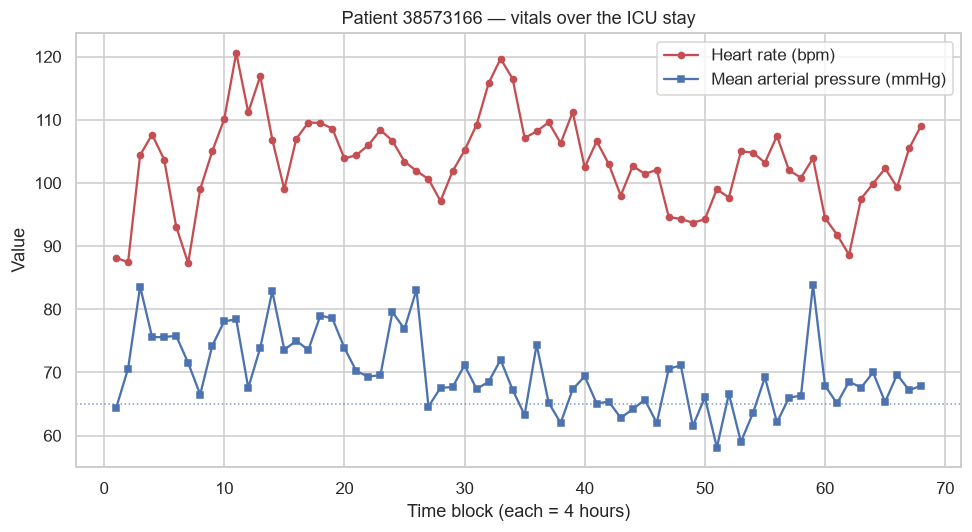

In [16]:
fig, ax = plt.subplots()
ax.plot(one["bloc"], one["HR"], marker="o", ms=4, color="#C44E52", label="Heart rate (bpm)")
ax.plot(one["bloc"], one["MeanBP"], marker="s", ms=4, color="#4C72B0", label="Mean arterial pressure (mmHg)")
ax.axhline(65, color="#4C72B0", ls=":", lw=1, alpha=.7)   # MAP target
ax.set(title=f"Patient {pid} — vitals over the ICU stay",
       xlabel="Time block (each = 4 hours)", ylabel="Value")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** You can read the physiology straight off the line: as MAP drifts
> toward and below the 65 mmHg target (dotted line), heart rate climbs — a compensating tachycardia.
> This is *time-series* data, and the shape of these lines is where the predictive signal lives.
> Notebook 04 turns shapes like this into numbers a model can learn from.


## 👥 GroupBy — the clinician's best friend

`groupby` answers "**for each patient, what is …?**" It splits the table into per-patient chunks,
computes something on each, and stitches the answers back together. This is how you go from
37,704 blocks to **one row per patient**.

The simplest: **how many blocks** did each patient stay? (`.size()`)


In [17]:
blocks = df.groupby("icustayid").size()
blocks.describe()

count    1696.000000
mean       22.231132
std        18.591802
min         1.000000
25%         9.000000
50%        14.500000
75%        28.000000
max        69.000000
dtype: float64

One summary at a time is fine, but usually you want several **different** statistics of
**different** columns at once. `.agg()` takes a dictionary of `column: function`:


In [18]:
per_patient = df.groupby("icustayid").agg(
    n_blocks       = ("bloc", "size"),
    age            = ("age", "first"),      # constant within a stay -> "first"
    hr_mean        = ("HR", "mean"),
    map_min        = ("MeanBP", "min"),     # worst (lowest) blood pressure
    sofa_max       = ("SOFA", "max"),       # worst organ-failure score
    lactate_max    = ("Arterial_lactate", "max"),
    died_90d       = ("morta_90", "max"),
).reset_index()
per_patient.head()

,icustayid,n_blocks,age,hr_mean,map_min,sofa_max,lactate_max,died_90d
0,30003226,12,67,73.310833,87.25,7,2.00,0
1,30004576,7,36,95.707143,79.00,5,3.30,0
2,30004811,14,66,83.140714,59.17,8,3.00,0
3,30009596,9,77,60.840000,87.25,8,2.78,0
4,30011748,5,70,71.090000,90.29,3,2.40,0


That single command **is** the skeleton of the patient-level table the modelling notebooks
use. `reset_index()` turns the patient key back into a normal column (otherwise it hides in the
index). Now that we have one row per patient, comparing survivors and non-survivors is a one-liner:


In [19]:
per_patient.groupby("died_90d")[["age", "hr_mean", "map_min", "sofa_max", "lactate_max"]].mean()

,age,hr_mean,map_min,sofa_max,lactate_max
died_90d,,,,,
0,64.381399,82.572564,68.763641,6.835616,3.545854
1,71.255663,86.879956,64.065049,8.637540,4.292524


Let's make that comparison visual — worst SOFA score, split by outcome:


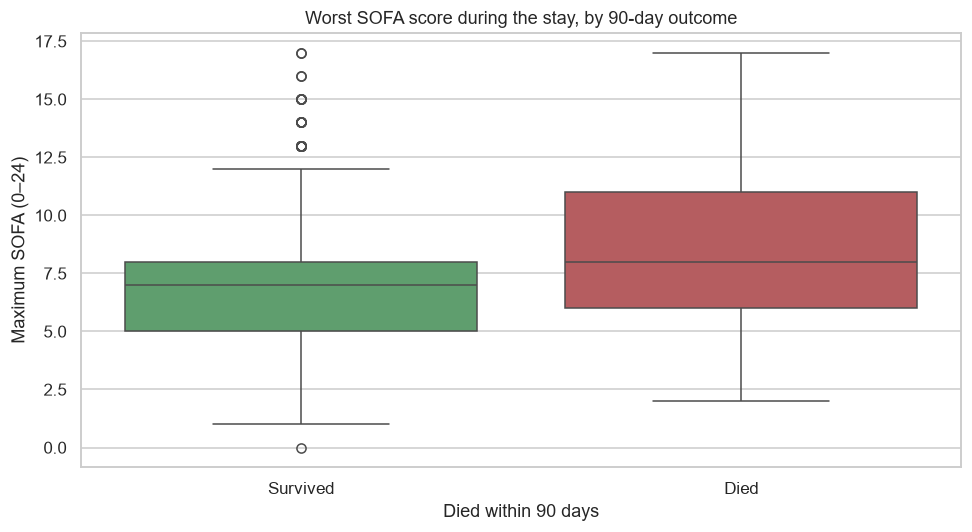

In [20]:
fig, ax = plt.subplots()
sns.boxplot(data=per_patient, x="died_90d", y="sofa_max",
            hue="died_90d", palette=["#55A868", "#C44E52"], legend=False, ax=ax)
ax.set(title="Worst SOFA score during the stay, by 90-day outcome",
       xlabel="Died within 90 days", ylabel="Maximum SOFA (0–24)")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Survived", "Died"])
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** Patients who died reached **higher peak SOFA scores** — more organ
> failure. It's a clear signal, but the boxes overlap: SOFA alone won't perfectly predict outcome.
> That gap is why we build multivariable models later in the course.


### ✏️ Your turn — exercise 2

Build a per-patient summary of **kidney function**: for each `icustayid`, compute the
**maximum `Creatinine`** and the **mean `BUN`**, then show the 5 patients with the highest peak
creatinine.


In [21]:
# TODO: groupby icustayid, aggregate creatinine max and BUN mean, then sort
kidney = ...
# kidney.sort_values(...).head()

<details><summary>💡 Show solution</summary>

```python
kidney = df.groupby("icustayid").agg(
    creatinine_max = ("Creatinine", "max"),
    bun_mean       = ("BUN", "mean"),
).reset_index()
kidney.sort_values("creatinine_max", ascending=False).head()
```
</details>


## 🕒 Working with dates and times

Every row carries a `timestep` — a UNIX timestamp (seconds since 1970). The absolute dates are
**shifted** to protect privacy, but the **intervals are real**: consecutive blocks are exactly
4 hours (14,400 s) apart. Convert seconds to a proper datetime with `pd.to_datetime(..., unit="s")`:


In [22]:
df["dt"] = pd.to_datetime(df["timestep"], unit="s")
df[["icustayid", "bloc", "timestep", "dt"]].head()

,icustayid,bloc,timestep,dt
0,30003226,1,4833101040,2123-02-26 16:04:00
1,30003226,2,4833115440,2123-02-26 20:04:00
2,30003226,3,4833129840,2123-02-27 00:04:00
3,30003226,4,4833144240,2123-02-27 04:04:00
4,30003226,5,4833158640,2123-02-27 08:04:00


The dates look like the 2110s — that's the de-identification shift, not a bug. What matters is
**elapsed time within a stay**. We compute *hours since admission* for every row using
`groupby(...).transform("min")`, which broadcasts each patient's first timestamp back onto all
their rows (so we can subtract it):


In [23]:
first_ts = df.groupby("icustayid")["timestep"].transform("min")
df["hours_since_admit"] = (df["timestep"] - first_ts) / 3600
df[["icustayid", "bloc", "hours_since_admit"]].head()

,icustayid,bloc,hours_since_admit
0,30003226,1,0.0
1,30003226,2,4.0
2,30003226,3,8.0
3,30003226,4,12.0
4,30003226,5,16.0


> 🧠 **Clinical takeaway.** `transform` is the trick to remember: unlike `agg` (which returns
> one row per patient), `transform` returns a value for **every original row**, aligned back in
> place. It's perfect for "distance from this patient's baseline" features — hours since admission,
> change from first lactate, and so on. Notice `hours_since_admit` is just `(bloc − 1) × 4`, which
> confirms the clean 4-hour spacing.

The `.dt` accessor exposes calendar parts (`.dt.hour`, `.dt.dayofweek`, …). And if your timestamps
were irregular, `df.set_index("dt").resample("8H")` would re-bin them to fixed 8-hour windows —
we don't need it here because our blocks are already regular, but it's the go-to tool for ragged
clinical time series.


## 🔄 Reshaping — pivot and melt

Sometimes you want data as a **grid**. A `pivot_table` cross-tabulates: here, **average heart rate
for each time block, split by outcome**. Rows = block number, columns = survived/died.


In [24]:
pivot = df.pivot_table(index="bloc", columns="morta_90", values="HR", aggfunc="mean")
pivot.columns = ["Survived", "Died"]
pivot.head(10)

,Survived,Died
bloc,,
1,85.650476,90.207314
2,83.719751,88.009800
3,83.159898,86.125380
4,82.736549,85.989064
5,82.683579,86.154054
6,82.647001,86.182837
7,82.210831,86.405536
8,82.069590,86.396458
9,82.162595,86.296332


Plotting the first ≈24 blocks (four days) shows the two groups **diverging over time** — a
recurring, powerful pattern in this course:


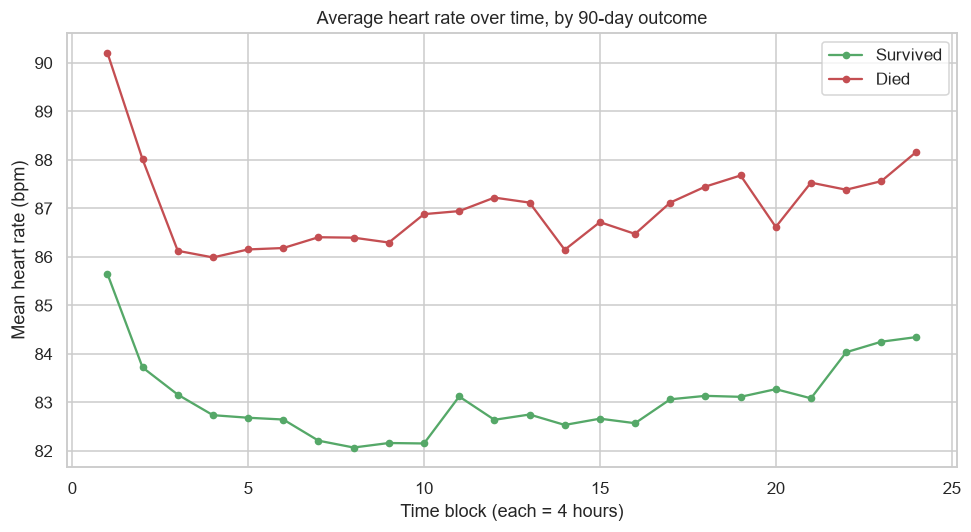

In [25]:
early = pivot.loc[pivot.index <= 24]
fig, ax = plt.subplots()
ax.plot(early.index, early["Survived"], marker="o", ms=4, color="#55A868", label="Survived")
ax.plot(early.index, early["Died"],     marker="o", ms=4, color="#C44E52", label="Died")
ax.set(title="Average heart rate over time, by 90-day outcome",
       xlabel="Time block (each = 4 hours)", ylabel="Mean heart rate (bpm)")
ax.legend()
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** From the very first blocks, patients who will die run a **higher
> average heart rate**, and the gap persists. A model doesn't have to be clever to pick up on this —
> but *we* had to reshape the data into the right grid to see it.

The opposite of pivoting is **`melt`**: it turns wide columns into long "tidy" rows — one row per
value — which is exactly the format seaborn likes for coloured/grouped plots.


In [26]:
wide = per_patient[["icustayid", "hr_mean", "map_min"]].head(3)
long = wide.melt(id_vars="icustayid", var_name="measure", value_name="value")
print("WIDE:\n", wide, "\n\nLONG (melted):\n", long)

WIDE:
    icustayid    hr_mean  map_min
0   30003226  73.310833    87.25
1   30004576  95.707143    79.00
2   30004811  83.140714    59.17 

LONG (melted):
    icustayid  measure      value
0   30003226  hr_mean  73.310833
1   30004576  hr_mean  95.707143
2   30004811  hr_mean  83.140714
3   30003226  map_min  87.250000
4   30004576  map_min  79.000000
5   30004811  map_min  59.170000


## 🔗 Merging two tables

Real projects spread information across several tables — vitals in one, outcomes or demographics in
another — joined on a shared **key**. Let's build a tiny per-patient **outcomes** table and
`merge` it back onto the time-series, keyed on `icustayid` (the SQL `JOIN` you may know):


In [27]:
outcomes = df.groupby("icustayid").agg(
    died_90d      = ("morta_90", "max"),
    died_in_hosp  = ("died_in_hosp", "max"),
    los_hours     = ("bloc", "max"),
).reset_index()
outcomes["los_hours"] = outcomes["los_hours"] * 4
outcomes.head()

,icustayid,died_90d,died_in_hosp,los_hours
0,30003226,0,0,48
1,30004576,0,0,28
2,30004811,0,0,56
3,30009596,0,0,36
4,30011748,0,0,20


In [28]:
merged = df.merge(outcomes, on="icustayid", how="left")
print("Before merge:", df.shape, " After merge:", merged.shape)
merged[["icustayid", "bloc", "HR", "died_90d", "los_hours"]].head()

Before merge: (37704, 55)  After merge: (37704, 58)


,icustayid,bloc,HR,died_90d,los_hours
0,30003226,1,83.40,0,48
1,30003226,2,69.71,0,48
2,30003226,3,66.25,0,48
3,30003226,4,72.12,0,48
4,30003226,5,75.25,0,48


> 🧠 **Clinical takeaway.** `how="left"` keeps **every** left-hand row and attaches matching
> info from the right — no patient is dropped. Getting the **key** and the **join type** right is
> where merges go wrong: a bad key silently duplicates or loses rows. Always sanity-check the shape
> before and after, as we did above.


### ✏️ Your turn — exercise 3

Compute each patient's **length of stay in hours** (`n_blocks × 4`) and their **90-day outcome**,
then find the **mean length of stay for survivors vs non-survivors**. Does one group stay longer?


In [29]:
# TODO: build a per-patient table with los_hours and died_90d, then compare means
summary = ...
# summary.groupby("died_90d")["los_hours"].mean()

<details><summary>💡 Show solution</summary>

```python
summary = df.groupby("icustayid").agg(
    n_blocks = ("bloc", "max"),
    died_90d = ("morta_90", "max"),
).reset_index()
summary["los_hours"] = summary["n_blocks"] * 4
print(summary.groupby("died_90d")["los_hours"].mean().round(1))
# Non-survivors often have shorter stays (early deaths) — a subtle, important pattern.
```
</details>


## 🕳️ A first look at missing data

You saw hints in `df.info()`. Let's quantify it: `isna().sum()` counts the blanks in each column,
and sorting shows the worst offenders.


In [30]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_pct[missing_pct > 0].head(12)

SaO2         93.8
Height_cm    39.6
Weight_kg     9.0
dtype: float64

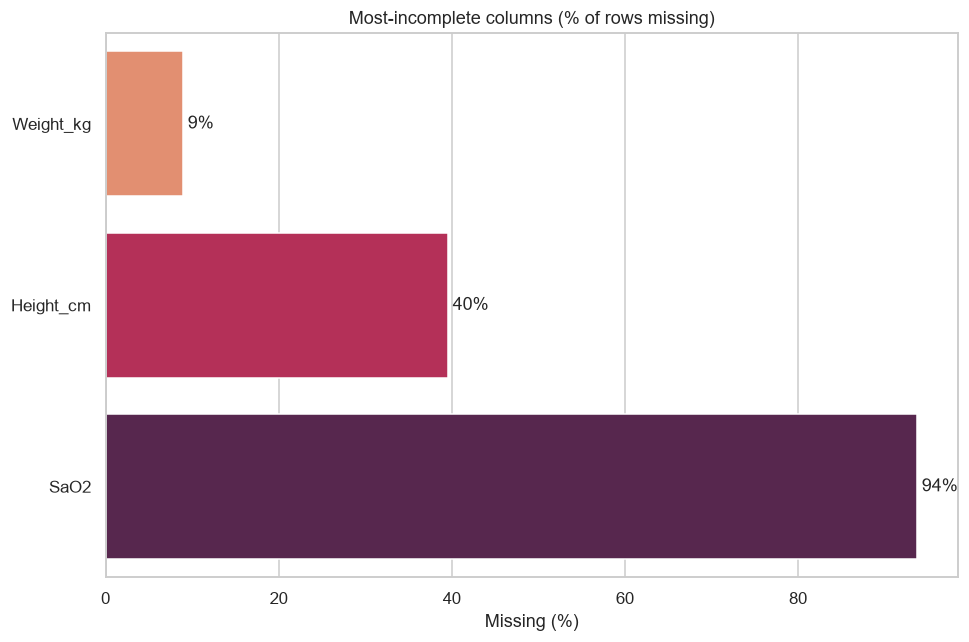

In [31]:
top = missing_pct[missing_pct > 0].head(12).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="rocket_r", legend=False, ax=ax)
ax.set(title="Most-incomplete columns (% of rows missing)",
       xlabel="Missing (%)", ylabel="")
for i, v in enumerate(top.values):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** `SaO2` is missing in ≈95% of blocks, `Height_cm` in ≈40% — these are
> tests that simply aren't run every 4 hours, not errors. A column that's 95% empty may be worth
> **dropping**; one that's 40% empty you'll want to **impute** thoughtfully. And crucially, in a
> time series you impute **per patient, forward in time** — never by borrowing from the future.
> That's the whole subject of **Notebook 02**, where we clean this dataset properly.


## ✅ Recap

You can now navigate a real longitudinal ICU table:

- The data is **one row per patient (`icustayid`) per 4-hour block (`bloc`)**; the outcome is `morta_90`.
- **Select** columns with `df[[...]]`; **filter** rows with boolean masks, `.loc`, `.iloc`, `.query()`.
- **`groupby("icustayid")`** collapses many blocks into per-patient answers via `.size()`, `.agg()`, etc.
- **`.transform()`** broadcasts a per-group value back onto every row (e.g. hours since admission).
- **`pivot_table`** makes grids, **`melt`** makes tidy long form, **`merge`** joins tables on a key.
- Real data has **missing values and impossible readings** — we found them but haven't fixed them yet.


## ➡️ Next

**Notebook 02 — Cleaning messy clinical data.** We hunt down every intentional artifact in this
dataset — the 3900 °F temperatures, the heart rates of 0, the duplicate rows, the 95%-empty
columns — and fix them **without destroying real signal**, using time-series-aware, per-patient
imputation. See you there. 🧹


<!-- nav-footer -->
---

### ➡️ Next up — Notebook 02: Cleaning messy clinical data

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 02 in Colab" height="32"/></a>

👉 **[Continue to Notebook 02 — Cleaning messy clinical data](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/02_data_cleaning.ipynb)**

[⬅ Back to Notebook 00](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)